# EM results — synaptic ultrastructure in neocortical epilepsy

Figures 8–11 and the statistics of Results section 2 / Methods 2.4.

Input: the ImageJ ROI export CSVs `AZ_all.csv`, `PD_all.csv`, `PC_all.csv`, `CL_all.csv` (active zone, postsynaptic density, photoconverted and clear vesicles). Conditions: v = Control, d = Acute (10 d), e = Chronic (45 d).

In [1]:
%matplotlib inline
# --- Imports and configuration --------------------------------------------
import os, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import scikit_posthocs as sph           # Dunn post-hoc test (imported as sph)

# Repo-relative path to the EM data (AZ/PD/PC/CL_all.csv); override with EM_DATA_DIR.
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == 'Codes' else HERE
DATA_DIR = os.environ.get('EM_DATA_DIR') or str(ROOT / 'data' / 'EM')
# Condition codes, display labels, and the blue / red / green palette.
COND=['v','d','e']; LAB={'v':'Control','d':'Acute','e':'Chronic'}
COL={'v':'#4C72B0','d':'#C44E52','e':'#55A868'}; AZ_COLOR,PSD_COLOR='#4C72B0','#C44E52' 

## 1. Load data (per-vesicle positions + per-synapse summary)

In [2]:
# --- Calibration and geometry / data-loading helpers ---------------------
PIXEL_NM = 2.375          # nm per pixel (EM calibration)

PIXEL_UM = PIXEL_NM / 1000

# ---- unified blue / red / green condition palette (seaborn "deep") ----

# Parse the "[[x y] ...]" ROI coordinate string from the CSV into an (N,2) array.
def parse_coords(s):
    nums = list(map(float, re.findall(r"-?\d+\.?\d*", str(s))))
    return np.array(nums).reshape(-1, 2)

# Load one ROI CSV (AZ/PD/PC/CL) and parse its coordinate column.
def load_df(name):
    df = pd.read_csv(os.path.join(DATA_DIR, name), index_col=0)
    df["coords"] = df["coords"].map(parse_coords)
    return df

# Shortest distance from point v to the line segment A-B (used for vesicle-to-AZ distance).
def point_to_segment(v, A, B):
    x0, y0 = v; x1, y1 = A; x2, y2 = B
    if x2 == x1:
        if min(y1, y2) <= y0 <= max(y1, y2):
            return abs(x0 - x1)
        return min(np.hypot(x0 - x1, y0 - y1), np.hypot(x0 - x2, y0 - y2))
    a = (y2 - y1) / (x2 - x1); b = y1 - a * x1
    xp = (x0 + a * (y0 - b)) / (a * a + 1); yp = a * xp + b
    if min(x1, x2) <= xp <= max(x1, x2) and min(y1, y2) <= yp <= max(y1, y2):
        return abs(a * x0 - y0 + b) / np.sqrt(a * a + 1)
    return min(np.hypot(x0 - x1, y0 - y1), np.hypot(x0 - x2, y0 - y2))

# Distance from a vesicle to the AZ polyline = min distance over its segments.
def vesicle_to_AZ(ves, AZ):
    return min(point_to_segment(ves, AZ[i], AZ[i + 1]) for i in range(len(AZ) - 1))

# Order the AZ points along their main axis and return a 0-1 position for each.
def normalize_AZ(AZ):
    AZ = np.asarray(AZ)
    _, idx = np.unique(AZ, axis=0, return_index=True)
    AZ = AZ[np.sort(idx)]
    _, _, vh = np.linalg.svd(AZ - AZ.mean(axis=0))
    AZ = AZ[np.argsort(AZ @ vh[0])]
    seg = np.linalg.norm(np.diff(AZ, axis=0), axis=1)
    cum = np.concatenate([[0], np.cumsum(seg)])
    return AZ, (cum / cum[-1] if cum[-1] > 0 else cum)

# Project a vesicle onto the AZ and return its normalized (0-1) position along it.
def project_to_normAZ(ves, AZ, npos):
    ves = np.asarray(ves); best, bn = np.inf, None
    for i in range(len(AZ) - 1):
        A, B = AZ[i], AZ[i + 1]; AB = B - A; den = np.dot(AB, AB)
        if den == 0:
            continue
        t = np.dot(ves - A, AB) / den
        d = np.linalg.norm(ves - (A + t * AB))
        if d < best:
            best, bn = d, npos[i] + t * (npos[i + 1] - npos[i])
    return bn

# Total length of a polyline (AZ or PSD trace) in micrometres.
def polyline_length_um(coords):
    if len(coords) < 2:
        return np.nan
    return np.sum(np.linalg.norm(np.diff(coords, axis=0), axis=1)) * PIXEL_UM

# Assemble the per-vesicle position tables and the per-synapse summary table.
def build_dataframes():
    AZ = load_df("AZ_all.csv"); PD = load_df("PD_all.csv")
    PC = load_df("PC_all.csv"); CL = load_df("CL_all.csv")

    # normalized vesicle positions + distance to AZ (per vesicle)
    def norm_table(vesdf):
        rows = []
        for cid in vesdf.index:
            AZc = AZ.loc[cid, "coords"]; cond = vesdf.loc[cid, "condition"]
            AZo, AZn = normalize_AZ(AZc)
            for v in vesdf.loc[cid, "coords"]:
                rows.append([cid, cond,
                             project_to_normAZ(v, AZo, AZn),
                             vesicle_to_AZ(v, AZc)])
        return pd.DataFrame(rows, columns=["cell_id", "condition", "x_norm", "y_dist"])

    norm_pc = norm_table(PC); norm_cl = norm_table(CL)   # per-vesicle position tables

    # per-synapse summary
    pc_n = norm_pc.groupby("cell_id").size()
    cl_n = norm_cl.groupby("cell_id").size()
    # one row per synapse: vesicle counts, released fraction, AZ & PSD length
    syn = PD[["condition"]].copy()
    syn["pc"] = syn.index.map(pc_n).fillna(0)
    syn["cl"] = syn.index.map(cl_n).fillna(0)
    syn["total"] = syn["pc"] + syn["cl"]
    syn["ratio"] = syn["pc"] / syn["total"]
    syn["az_len"] = AZ["coords"].map(polyline_length_um)
    syn["pd_len"] = PD["coords"].map(polyline_length_um)
    syn["avg_pc_dist"] = norm_pc.groupby("cell_id")["y_dist"].mean() * PIXEL_UM
    syn = syn.dropna(subset=["ratio"])
    return norm_pc, norm_cl, syn


# ----------------------------------------------------------------------
# small plotting helpers
# ----------------------------------------------------------------------


In [3]:
# Build the analysis tables from the raw ROI coordinates:
#   norm_pc / norm_cl = one row per photoconverted / clear vesicle (position + distance to AZ)
#   syn               = one row per synapse (vesicle counts, released fraction, AZ & PSD length)
norm_pc, norm_cl, syn = build_dataframes()
print('synapses per condition:', {LAB[c]: int((syn.condition==c).sum()) for c in COND})
print('PC vesicles:', len(norm_pc), ' CL vesicles:', len(norm_cl))

synapses per condition: {'Control': 51, 'Acute': 58, 'Chronic': 147}
PC vesicles: 1105  CL vesicles: 12168


## 2. Statistics (Methods 2.4)

In [ ]:
# p-value -> significance stars.
def stars(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
def holm2(p1,p2):
    o=sorted([(0,p1),(1,p2)],key=lambda z:z[1]); a={}
    a[o[0][0]]=min(o[0][1]*2,1); a[o[1][0]]=max(min(o[1][1],1),a[o[0][0]]); return a

# 2.1 Are released (PC) vesicles positioned closer to the active zone than resting (CL) ones?
# Per condition: Kolmogorov-Smirnov test on the distance distributions, a docked-fraction chi-square
# (<=50 nm from AZ), and a per-synapse paired Wilcoxon on mean PC vs CL distance.
print('=== 2.1 Spatial reorganization of released (PC) vs resting (CL) vesicles ===')
DOCK_NM=50                                     # "docked" = within 50 nm of the AZ
for ck in COND:
    pc=norm_pc[norm_pc.condition==ck].y_dist.values*PIXEL_NM     # PC vesicle-to-AZ distances (nm)
    cl=norm_cl[norm_cl.condition==ck].y_dist.values*PIXEL_NM     # CL vesicle-to-AZ distances (nm)
    D,pks=stats.ks_2samp(pc,cl)                                  # distributions differ?
    d=pd.concat([pd.DataFrame({'dist':pc,'pc':1}),pd.DataFrame({'dist':cl,'pc':0})]); dock=d.dist<=DOCK_NM
    chi2,pchi,_,_=stats.chi2_contingency(pd.crosstab(dock,d.pc))  # is PC enriched among docked vesicles?
    # per-synapse means, paired PC vs CL within each synapse
    pcm=norm_pc[norm_pc.condition==ck].groupby('cell_id').y_dist.mean()*PIXEL_NM
    clm=norm_cl[norm_cl.condition==ck].groupby('cell_id').y_dist.mean()*PIXEL_NM
    both=pd.concat([pcm.rename('pc'),clm.rename('cl')],axis=1).dropna(); _,pw=stats.wilcoxon(both.pc,both.cl)
    print(f'  {LAB[ck]:8s} KS: PC {np.median(pc):.0f} vs CL {np.median(cl):.0f} nm, D={D:.2f} p={pks:.4f} {stars(pks)} | '
          f'docked PC {d[dock].pc.mean():.2f} vs undocked {d[~dock].pc.mean():.2f} chi2 p={pchi:.2g} {stars(pchi)} | '
          f'paired Wilcoxon p={pw:.3f} {stars(pw)}')

=== 2.1 Spatial reorganization of released (PC) vs resting (CL) vesicles ===
  Control  KS: PC 193 vs CL 234 nm, D=0.16 p=0.0006 *** | docked PC 0.17 vs undocked 0.06 chi2 p=2.2e-05 *** | paired Wilcoxon p=0.007 **
  Acute    KS: PC 203 vs CL 259 nm, D=0.14 p=0.0012 ** | docked PC 0.11 vs undocked 0.06 chi2 p=0.0033 ** | paired Wilcoxon p=0.172 ns
  Chronic  KS: PC 207 vs CL 207 nm, D=0.04 p=0.1977 ns | docked PC 0.11 vs undocked 0.10 chi2 p=0.42 ns | paired Wilcoxon p=0.188 ns


In [5]:
# 2.2 Released (photoconverted) vesicle fraction PC/(PC+CL) across conditions.
print('=== 2.2 Photoconverted vesicle fraction PC/(PC+CL) — Kruskal-Wallis + Dunn ===')
gr=[syn.loc[syn.condition==c,'ratio'].dropna().values for c in COND]
for c,v in zip(COND,gr): print(f'  {LAB[c]:8s} median={np.median(v):.3f} IQR=[{np.percentile(v,25):.3f}, {np.percentile(v,75):.3f}]')
h,pk=stats.kruskal(*gr); print(f'  Kruskal-Wallis p={pk:.4f}')          # omnibus across conditions
dn=sph.posthoc_dunn(gr,p_adjust='holm')                                 # pairwise post-hoc
print(f'  Dunn Acute vs Chronic p={dn.iloc[1,2]:.4f} {stars(dn.iloc[1,2])} | Chronic vs Control p={dn.iloc[0,2]:.3f} | Acute vs Control p={dn.iloc[0,1]:.3f}')

# 2.3 PSD and AZ length across conditions (Kruskal-Wallis + Dunn, Holm-corrected).
print('=== 2.3 PSD and AZ length — Kruskal-Wallis + Dunn (Holm) ===')
psd={c:syn.loc[syn.condition==c,'pd_len'].dropna().values for c in COND}
az={c:syn.loc[syn.condition==c,'az_len'].dropna().values for c in COND}
for nm,dd in [('PSD',psd),('AZ',az)]:
    print(f'  {nm} medians:', {LAB[c]: round(float(np.median(dd[c])),3) for c in COND})
_pd=sph.posthoc_dunn([psd['v'],psd['d'],psd['e']],p_adjust='holm')       # PSD pairwise vs Control
print(f'  PSD Dunn vs Control: Acute p={_pd.iloc[0,1]:.3f} {stars(_pd.iloc[0,1])}  Chronic p={_pd.iloc[0,2]:.3f} {stars(_pd.iloc[0,2])}')
print(f'  PSD Kruskal-Wallis p={stats.kruskal(*psd.values())[1]:.3f}')
paz=sph.posthoc_dunn([az['v'],az['d'],az['e']],p_adjust='holm').iloc[1,2]  # AZ acute vs chronic
print(f'  AZ Acute vs Chronic (Dunn) p={paz:.4f} {stars(paz)}')

# 2.4 Does PSD length track vesicle measures within each condition? (Spearman)
print('=== 2.4 PSD length vs vesicle measures — Spearman ===')
for c in COND:
    s=syn[syn.condition==c]
    rt,pt=stats.spearmanr(s.pd_len,s.total,nan_policy='omit'); rf,pf=stats.spearmanr(s.pd_len,s.ratio,nan_policy='omit')
    print(f'  {LAB[c]:8s} vs total vesicles rho={rt:.2f} p={pt:.3f} {stars(pt)} | vs released fraction rho={rf:.2f} p={pf:.2f}')

=== 2.2 Photoconverted vesicle fraction PC/(PC+CL) — Kruskal-Wallis + Dunn ===
  Control  median=0.071 IQR=[0.054, 0.093]
  Acute    median=0.065 IQR=[0.046, 0.099]
  Chronic  median=0.086 IQR=[0.064, 0.130]
  Kruskal-Wallis p=0.0040
  Dunn Acute vs Chronic p=0.0087 ** | Chronic vs Control p=0.052 | Acute vs Control p=0.601
=== 2.3 PSD and AZ length — Kruskal-Wallis + Dunn (Holm) ===
  PSD medians: {'Control': 0.366, 'Acute': 0.315, 'Chronic': 0.308}
  AZ medians: {'Control': 0.32, 'Acute': 0.369, 'Chronic': 0.279}
  PSD Dunn vs Control: Acute p=0.116 ns  Chronic p=0.028 *
  PSD Kruskal-Wallis p=0.032
  AZ Acute vs Chronic (Dunn) p=0.0002 ***
=== 2.4 PSD length vs vesicle measures — Spearman ===
  Control  vs total vesicles rho=-0.04 p=0.760 ns | vs released fraction rho=-0.09 p=0.52
  Acute    vs total vesicles rho=0.27 p=0.041 * | vs released fraction rho=-0.06 p=0.68
  Chronic  vs total vesicles rho=0.24 p=0.003 ** | vs released fraction rho=-0.03 p=0.73


In [6]:
# 2.5 Active-zone / PSD size coupling and relative-size balance (per synapse)
print('=== 2.5 AZ-PSD coupling (Spearman within condition) and balance (AZ - PSD) ===')
# Coupling: do AZ length and PSD length co-vary within each condition?
for c in COND:
    s = syn[syn.condition == c][['az_len', 'pd_len']].dropna()
    rho, p = stats.spearmanr(s.az_len, s.pd_len)
    print(f'  {LAB[c]:8s} n={len(s):3d}  Spearman AZ~PSD rho={rho:+.2f} p={p:.2g}')

# Balance: per-synapse (AZ - PSD) difference across conditions
syn['az_psd_diff'] = syn['az_len'] - syn['pd_len']
grp = {c: syn[syn.condition == c]['az_psd_diff'].dropna().values for c in COND}
H, p = stats.kruskal(*[grp[c] for c in COND])
print('\n  AZ-PSD difference medians: ' + ', '.join(f'{LAB[c]} {np.median(grp[c]):+.3f} um' for c in COND))
print(f'  Kruskal-Wallis H(2)={H:.1f}, p={p:.2g}')
dn = sph.posthoc_dunn(syn[['condition', 'az_psd_diff']].dropna(), val_col='az_psd_diff', group_col='condition', p_adjust='holm')

def eff_size(a, b):
    U, _ = stats.mannwhitneyu(a, b, alternative='two-sided')
    cliff = 1 - 2 * U / (len(a) * len(b))                      # rank-biserial / Cliff's delta
    sp = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) / (len(a)+len(b)-2))
    return cliff, (a.mean() - b.mean()) / sp                   # + Cohen's d

for a, b in [('d', 'v'), ('e', 'v')]:
    cliff, d = eff_size(grp[a], grp[b])
    print(f"  {LAB[a]} vs {LAB[b]}: Dunn p={dn.loc[a, b]:.2g}, Cliff's delta={cliff:+.2f}, Cohen's d={d:+.2f}")

=== 2.5 AZ-PSD coupling (Spearman within condition) and balance (AZ - PSD) ===
  Control  n= 51  Spearman AZ~PSD rho=+0.76 p=9.7e-11
  Acute    n= 58  Spearman AZ~PSD rho=+0.61 p=3.4e-07
  Chronic  n=147  Spearman AZ~PSD rho=+0.74 p=6.7e-27

  AZ-PSD difference medians: Control -0.030 um, Acute +0.044 um, Chronic -0.012 um
  Kruskal-Wallis H(2)=37.0, p=9.2e-09
  Acute vs Control: Dunn p=2.8e-08, Cliff's delta=-0.59, Cohen's d=+1.00
  Chronic vs Control: Dunn p=0.04, Cliff's delta=-0.21, Cohen's d=+0.36


## 3. Figures

### Figure 11 — spatial distribution of released (PC) and resting (CL) vesicles

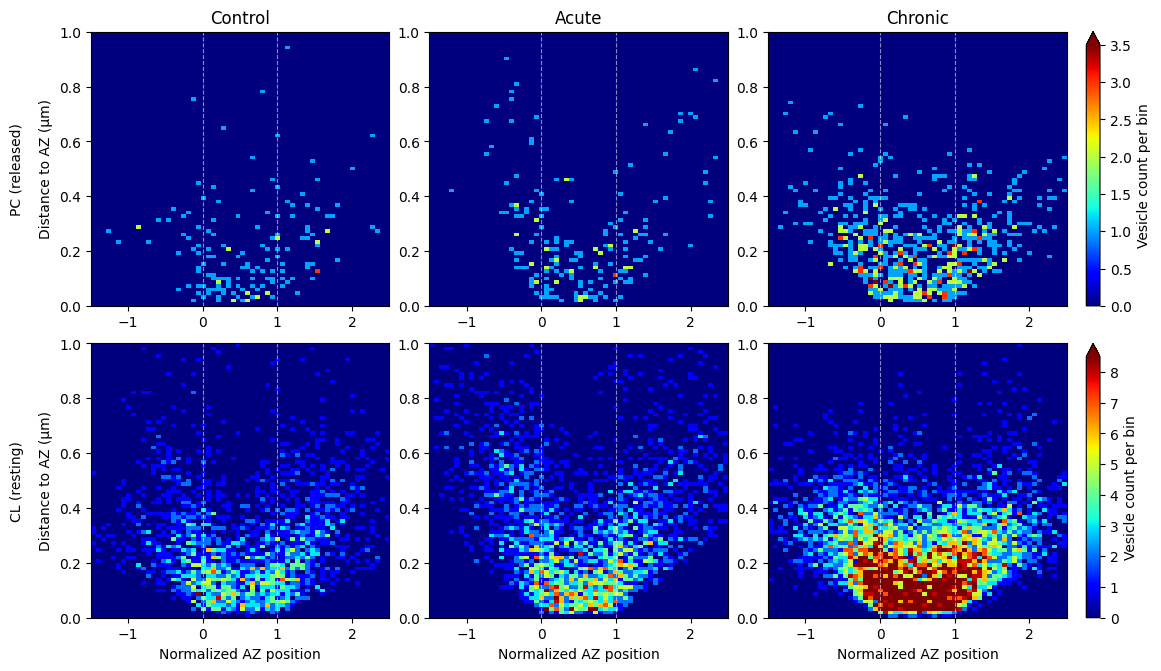

In [7]:
# Figure 11 - 2D density of vesicle positions relative to the active zone.
# Rows = PC (released) / CL (resting); columns = the three conditions.
# x = position along the normalized AZ (0-1), y = distance from the AZ (µm).
XR,YR=(-1.5,2.5),(0,1.0); NX,NY=60,75                 # plot ranges and 2D-histogram bin counts
fig,axes=plt.subplots(2,3,figsize=(11.5,6.6),constrained_layout=True)
rows=[('PC (released)',norm_pc,3.5),('CL (resting)',norm_cl,8.5)]   # (label, table, colour-scale max)
for r,(rlab,df,vmax) in enumerate(rows):
    for c,ck in enumerate(COND):
        ax=axes[r,c]; sub=df[df.condition==ck]
        H,_,_=np.histogram2d(sub.x_norm,sub.y_dist*PIXEL_UM,bins=[NX,NY],range=[XR,YR])   # bin vesicle positions
        im=ax.imshow(H.T,origin='lower',aspect='auto',cmap='jet',vmin=0,vmax=vmax,extent=[XR[0],XR[1],YR[0],YR[1]])
        ax.axvline(0,color='white',ls='--',lw=0.8,alpha=0.55); ax.axvline(1,color='white',ls='--',lw=0.8,alpha=0.55)  # AZ extent
        ax.set_yticks([0,0.2,0.4,0.6,0.8,1.0])
        if r==0: ax.set_title(LAB[ck])
        if r==1: ax.set_xlabel('Normalized AZ position')
        if c==0: ax.set_ylabel(f'{rlab}\nDistance to AZ (µm)',linespacing=2.4)
        if c==2: last=im
    cb=fig.colorbar(last,ax=axes[r,:],fraction=0.045,pad=0.02,extend='max'); cb.set_label('Vesicle count per bin',fontsize=10)
plt.savefig('../figures/Figure11.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 12 — released (photoconverted) vesicle fraction PC/(PC+CL)

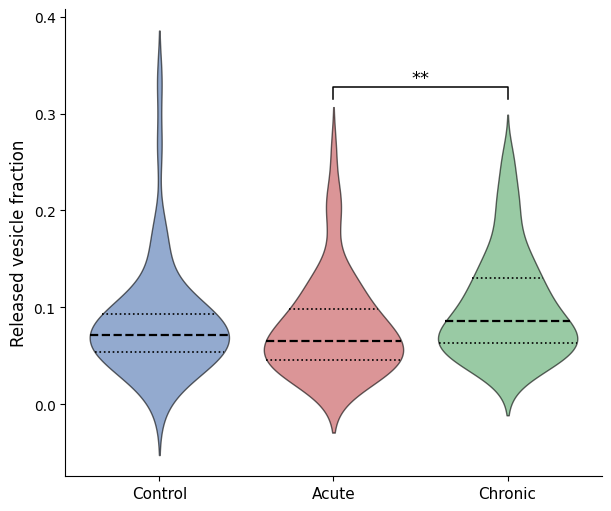

In [8]:
# Figure 12 - released vesicle fraction PC/(PC+CL) per condition, as violin plots.
gr=[syn.loc[syn.condition==c,'ratio'].dropna().values for c in COND]
p_ac=sph.posthoc_dunn(gr,p_adjust='holm').iloc[1,2]         # acute-vs-chronic p for the bracket
fig,ax=plt.subplots(figsize=(6,5),constrained_layout=True); HALF=0.4; CUT=2
for i,ck in enumerate(COND):
    # kernel-density estimate -> symmetric violin shape for this condition
    v=gr[i]; kde=stats.gaussian_kde(v); ext=CUT*kde.factor*np.std(v,ddof=1)
    ys=np.linspace(v.min()-ext,v.max()+ext,400); dens=kde(ys); mx=dens.max(); hw=HALF*dens/mx
    ax.fill_betweenx(ys,i-hw,i+hw,facecolor=COL[ck],alpha=0.6,edgecolor='black',linewidth=1.0,zorder=2)
    # median (dashed) and quartiles (dotted) drawn at the violin width
    q1,med,q3=np.percentile(v,[25,50,75])
    for q,ls,lw in [(med,'--',1.6),(q1,':',1.2),(q3,':',1.2)]:
        hwq=HALF*kde(q)[0]/mx; ax.plot([i-hwq,i+hwq],[q,q],color='black',ls=ls,lw=lw,zorder=4)
ax.set_xticks(range(3)); ax.set_xticklabels([LAB[c] for c in COND],fontsize=11)
ax.set_ylabel('Released vesicle fraction',fontsize=12); ax.spines[['top','right']].set_visible(False)
ymax=max(np.percentile(gg,99) for gg in gr)
ax.plot([1,1,2,2],[ymax*1.05,ymax*1.09,ymax*1.09,ymax*1.05],color='black',lw=1.1)   # acute-chronic bracket
def stars(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
ax.text(1.5,ymax*1.09,stars(p_ac),ha='center',va='bottom',fontsize=13); plt.savefig('../figures/Figure12.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 13 — postsynaptic-density (A) and active-zone (B) length

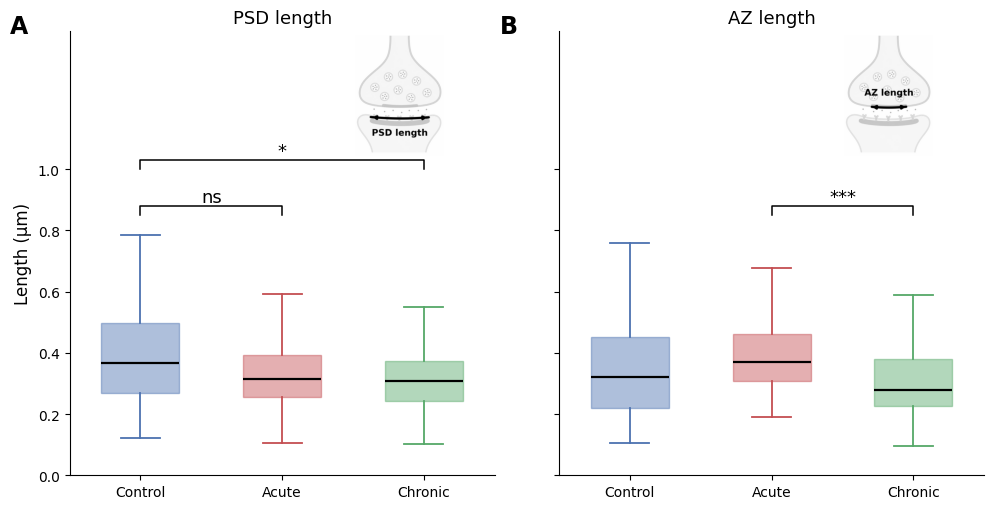

In [9]:
# Figure 13 - PSD length (A) and AZ length (B) per condition, boxplots.
psd={c:syn.loc[syn.condition==c,'pd_len'].dropna().values for c in COND}
az={c:syn.loc[syn.condition==c,'az_len'].dropna().values for c in COND}
def stars(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
# Dunn post-hoc: PSD vs Control (acute, chronic) and AZ acute-vs-chronic -> bracket labels
_pd=sph.posthoc_dunn([psd['v'],psd['d'],psd['e']],p_adjust='holm'); adj={0:_pd.iloc[0,1],1:_pd.iloc[0,2]}
p_az=sph.posthoc_dunn([az['v'],az['d'],az['e']],p_adjust='holm').iloc[1,2]
fig,(axA,axB)=plt.subplots(1,2,figsize=(10,5.2),sharey=True)
def brk(ax,x0,x1,y,l,pad):                               # draw one significance bracket
    ax.plot([x0,x0,x1,x1],[y,y+pad,y+pad,y],color='black',lw=1.1); ax.text((x0+x1)/2,y+pad,l,ha='center',va='bottom',fontsize=13)
# (axis, data, title, [(x0,x1,y,label) brackets]) for each panel
for ax,data,title,brs in [(axA,psd,'PSD length',[(0,1,0.85,stars(adj[0])),(0,2,1.0,stars(adj[1]))]),(axB,az,'AZ length',[(1,2,0.85,stars(p_az))])]:
    for i,c in enumerate(COND):
        bp=ax.boxplot(data[c],positions=[i],widths=0.55,patch_artist=True,showfliers=False,medianprops=dict(color='black',linewidth=1.6),
            whiskerprops=dict(color=COL[c],linewidth=1.3),capprops=dict(color=COL[c],linewidth=1.3))
        bp['boxes'][0].set_facecolor(COL[c]); bp['boxes'][0].set_alpha(0.45); bp['boxes'][0].set_edgecolor(COL[c])
    ax.set_xticks(range(3)); ax.set_xticklabels([LAB[c] for c in COND]); ax.set_title(title,fontsize=13)
    # extra headroom (ylim to 1.45, ticks to 1.0) leaves space for the synapse inset above the brackets
    ax.set_ylim(0,1.45); ax.set_yticks([0,0.2,0.4,0.6,0.8,1.0]); ax.spines[['top','right']].set_visible(False)
    for x0,x1,y,l in brs: brk(ax,x0,x1,y,l,0.03)
axA.set_ylabel('Length (µm)',fontsize=12)
for ax,l in [(axA,'A'),(axB,'B')]: ax.text(-0.14,1.04,l,transform=ax.transAxes,fontsize=17,fontweight='bold',va='top')
# add the schematic synapse insets (top-right of each panel) labelling PSD / AZ length
import matplotlib.image as _mpimg
for _ax,_fn in [(axA,'assets/inset_psd.png'),(axB,'assets/inset_az.png')]:
    _iax=_ax.inset_axes([0.55,0.71,0.45,0.29]); _iax.imshow(_mpimg.imread(_fn)); _iax.axis('off')
fig.tight_layout(); plt.savefig('../figures/Figure13.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 14 — PSD length vs vesicle measures (Spearman)

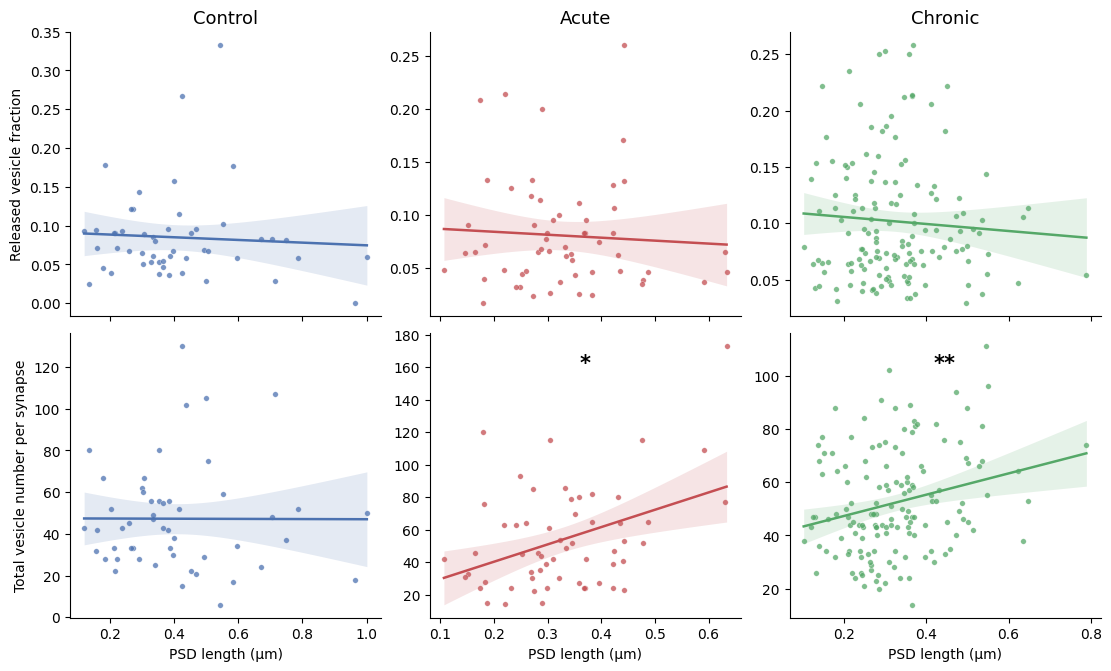

In [10]:
# Figure 14 - PSD length vs vesicle measures, per condition (columns), with
# a regression line + 95% CI band and a Spearman-significance star per panel.
def reg_ci(ax,x,y,color):
    # least-squares fit + 95% confidence band for the regression line
    x=np.asarray(x,float); y=np.asarray(y,float); m=np.isfinite(x)&np.isfinite(y); x,y=x[m],y[m]
    if len(x)<3: return
    sl,ic,*_=stats.linregress(x,y); xs=np.linspace(x.min(),x.max(),100); yh=ic+sl*xs
    resid=y-(ic+sl*x); s=np.sqrt(np.sum(resid**2)/(len(x)-2)); Sxx=np.sum((x-x.mean())**2)
    tval=stats.t.ppf(0.975,len(x)-2); ci=tval*s*np.sqrt(1/len(x)+(xs-x.mean())**2/Sxx)
    ax.plot(xs,yh,color=color,lw=1.8); ax.fill_between(xs,yh-ci,yh+ci,color=color,alpha=0.15,lw=0)
def stars(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else None
fig,axes=plt.subplots(2,3,figsize=(11,6.6),constrained_layout=True,sharex='col')
for c,ck in enumerate(COND):
    s=syn[syn.condition==ck]; col=COL[ck]
    # row 0 = released fraction vs PSD, row 1 = total vesicle number vs PSD
    for r,(yv,ylab) in enumerate([('ratio','Released vesicle fraction'),('total','Total vesicle number per synapse')]):
        ax=axes[r,c]; ax.scatter(s.pd_len,s[yv],s=16,color=col,alpha=0.75,edgecolor='white',linewidth=0.3); reg_ci(ax,s.pd_len,s[yv],col)
        rho,p=stats.spearmanr(s.pd_len,s[yv],nan_policy='omit'); mk=stars(p)   # Spearman significance
        if mk: ax.text(0.5,0.93,mk,transform=ax.transAxes,ha='center',va='top',fontsize=15,fontweight='bold')
        if r==0: ax.set_title(LAB[ck],fontsize=13)
        if r==1: ax.set_xlabel('PSD length (µm)')
        if c==0: ax.set_ylabel(ylab)
        ax.spines[['top','right']].set_visible(False)
plt.savefig('../figures/Figure14.png', dpi=200, bbox_inches='tight'); plt.show()